## 1. Import Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib Inline
import seaborn as sns

plt.style.use("default")
sns.set_context("notebook")

## 2. Load Dataset

In [3]:
df = pd.read_csv("nvidia_gpu_sales_synthetic_2026.csv")
df.head(4)

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,1796.91,12.38,Low Stock,4.0,12,Software Bundle,14375.30
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.0,12,NaN,32799.82
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,1308.25,30.96,Sold Out,4.0,12,NaN,39247.64
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,29202.11,8.16,Low Stock,4.5,24,NaN,146010.54


## 3. Basic Data Understanding

In [4]:
df.shape

(7000, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sale_id                      7000 non-null   int64  
 1   sale_date                    7000 non-null   object 
 2   gpu_model                    7000 non-null   object 
 3   gpu_family                   7000 non-null   object 
 4   launch_year                  7000 non-null   int64  
 5   region                       7000 non-null   object 
 6   sales_channel                7000 non-null   object 
 7   customer_segment             7000 non-null   object 
 8   units_sold                   7000 non-null   int64  
 9   msrp_usd                     7000 non-null   int64  
 10  avg_street_price_usd         7000 non-null   float64
 11  price_premium_pct            7000 non-null   float64
 12  stock_status                 7000 non-null   object 
 13  customer_satisfact

In [6]:
df.describe()

,sale_id,launch_year,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,customer_satisfaction_score,warranty_months,revenue_usd
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,3500.500000,2024.264429,21.674143,5212.903857,6042.141264,15.010536,4.428286,19.753714,5.658006e+04
std,2020.870275,1.100049,12.928136,11056.780783,12976.951044,14.348016,0.608437,8.637874,9.996269e+04
min,1.000000,2020.000000,1.000000,549.000000,549.050000,0.000000,1.500000,12.000000,1.393130e+03
25%,1750.750000,2024.000000,12.000000,749.000000,805.090000,4.560000,4.000000,12.000000,1.555133e+04
50%,3500.500000,2025.000000,20.000000,999.000000,1048.015000,8.850000,4.500000,24.000000,2.534293e+04
75%,5250.250000,2025.000000,29.000000,1599.000000,2002.570000,21.352500,5.000000,24.000000,4.670657e+04
max,7000.000000,2025.000000,104.000000,42000.000000,82364.480000,98.460000,5.000000,36.000000,1.225726e+06


In [7]:
df.columns

Index(['sale_id', 'sale_date', 'gpu_model', 'gpu_family', 'launch_year',
       'region', 'sales_channel', 'customer_segment', 'units_sold', 'msrp_usd',
       'avg_street_price_usd', 'price_premium_pct', 'stock_status',
       'customer_satisfaction_score', 'warranty_months', 'bundle_addon',
       'revenue_usd'],
      dtype='object')

## 4. Data Cleaning

### Check for missing values

In [8]:
df.isnull().sum().sort_values(ascending=False)

bundle_addon                   3841
sale_id                           0
msrp_usd                          0
warranty_months                   0
customer_satisfaction_score       0
stock_status                      0
price_premium_pct                 0
avg_street_price_usd              0
units_sold                        0
sale_date                         0
customer_segment                  0
sales_channel                     0
region                            0
launch_year                       0
gpu_family                        0
gpu_model                         0
revenue_usd                       0
dtype: int64

In [9]:
df["bundle_addon"].unique()

array(['Software Bundle', nan, 'Extended Warranty', 'Support Contract',
       'Cooling Kit', 'NVLink Cluster Install'], dtype=object)

In [10]:
df["bundle_addon"] = df["bundle_addon"].fillna("No bundle")
df.head(3)

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,1796.91,12.38,Low Stock,4.0,12,Software Bundle,14375.30
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.0,12,No bundle,32799.82
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,1308.25,30.96,Sold Out,4.0,12,No bundle,39247.64


### Checking for duplicate records

In [11]:
df.duplicated(subset=['sale_id', 'sale_date', 'gpu_model', 'gpu_family', 'launch_year',
       'region', 'sales_channel', 'customer_segment', 'units_sold', 'msrp_usd',
       'avg_street_price_usd', 'price_premium_pct', 'stock_status',
       'customer_satisfaction_score', 'warranty_months', 'bundle_addon',
       'revenue_usd']).any()

np.False_

In [12]:
df.duplicated().sum()

np.int64(0)

### Fixing Datatypes

In [13]:
df.dtypes

sale_id                          int64
sale_date                       object
gpu_model                       object
gpu_family                      object
launch_year                      int64
region                          object
sales_channel                   object
customer_segment                object
units_sold                       int64
msrp_usd                         int64
avg_street_price_usd           float64
price_premium_pct              float64
stock_status                    object
customer_satisfaction_score    float64
warranty_months                  int64
bundle_addon                    object
revenue_usd                    float64
dtype: object

In [14]:
df["sale_id"] = df["sale_id"].astype(str)
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")

In [15]:
categorical_cols = ["gpu_model", "gpu_family", "region", "sales_channel", "customer_segment", "bundle_addon"]
df[categorical_cols] = df[categorical_cols].astype("category")

In [16]:
df.dtypes

sale_id                                object
sale_date                      datetime64[ns]
gpu_model                            category
gpu_family                           category
launch_year                             int64
region                               category
sales_channel                        category
customer_segment                     category
units_sold                              int64
msrp_usd                                int64
avg_street_price_usd                  float64
price_premium_pct                     float64
stock_status                           object
customer_satisfaction_score           float64
warranty_months                         int64
bundle_addon                         category
revenue_usd                           float64
dtype: object

In [17]:
df.sample(10)

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
972,973,2025-04-04,B200,Data Center AI,2025,Asia-Pacific (ex-China),Cloud Provider,Hyperscale Datacenter,8,42000,55005.65,30.97,Backordered,5.0,24,No bundle,440045.23
2266,2267,2025-08-12,H200,Data Center AI,2024,Asia-Pacific (ex-China),Cloud Provider,Crypto Mining,4,35000,44677.52,27.65,Backordered,5.0,12,Support Contract,178710.10
6649,6650,2026-05-28,RTX 5070,Consumer Gaming,2025,China,Retail/Etail,Gaming,21,549,559.86,1.98,In Stock,4.5,12,No bundle,11757.15
4936,4937,2026-02-10,RTX 4080 Super,Consumer Gaming,2024,Europe,Retail/Etail,Gaming,23,999,1060.45,6.15,In Stock,5.0,24,No bundle,24390.33
3703,3704,2025-11-25,RTX 4070 Ti Super,Consumer Gaming,2024,Europe,Retail/Etail,Gaming,19,799,944.50,18.21,Backordered,4.0,36,No bundle,17945.45
4416,4417,2026-01-09,B200,Data Center AI,2025,China,Cloud Provider,Hyperscale Datacenter,9,42000,42048.29,0.11,In Stock,5.0,12,NVLink Cluster Install,378434.64
2181,2182,2025-08-07,RTX 4070 Ti Super,Consumer Gaming,2024,Europe,System Integrator/OEM,Gaming,10,799,952.43,19.20,Low Stock,4.0,24,Software Bundle,9524.31
5661,5662,2026-03-24,RTX 4070 Ti Super,Consumer Gaming,2024,Europe,Retail/Etail,Gaming,18,799,829.19,3.78,In Stock,5.0,12,Software Bundle,14925.36
684,685,2025-02-16,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),Retail/Etail,Gaming,15,799,818.63,2.46,In Stock,5.0,24,No bundle,12279.50
4474,4475,2026-01-12,RTX 5070,Consumer Gaming,2025,Europe,Retail/Etail,Gaming,20,549,845.84,54.07,Sold Out,2.0,12,No bundle,16916.85


In [18]:
# Check if price_premium_pct matches the actual calculation
df['calculated_premium'] = ((df['avg_street_price_usd'] - df['msrp_usd']) / df['msrp_usd']) * 100
df['premium_mismatch'] = abs(df['price_premium_pct'] - df['calculated_premium']) > 1  # allow small rounding tolerance
df[df['premium_mismatch']]

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd,calculated_premium,premium_mismatch


In [19]:
# Check if revenue matches the actual calculation
df['calculated_revenue'] = df['units_sold'] * df['avg_street_price_usd']
df['revenue_mismatch'] = abs(df['revenue_usd'] - df['calculated_revenue']) > 1
df[df['revenue_mismatch']]

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,...,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd,calculated_premium,premium_mismatch,calculated_revenue,revenue_mismatch


## 5. Data Analysis

### Univariate Analysis

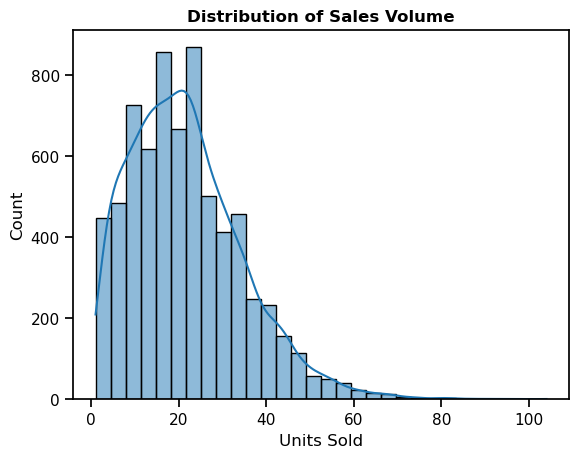

In [20]:
df["units_sold"].describe()
sns.histplot(df["units_sold"], bins = 30, kde=True)

plt.title("Distribution of Sales Volume", fontweight="bold")
plt.xlabel("Units Sold")
plt.show()

Sales volume is right-skewed, with most transactions falling between 10–30 units sold and a peak around 20–25 units, indicating typical demand clusters in this range while a smaller number of high-volume outliers (60+ units) pull the average upward.

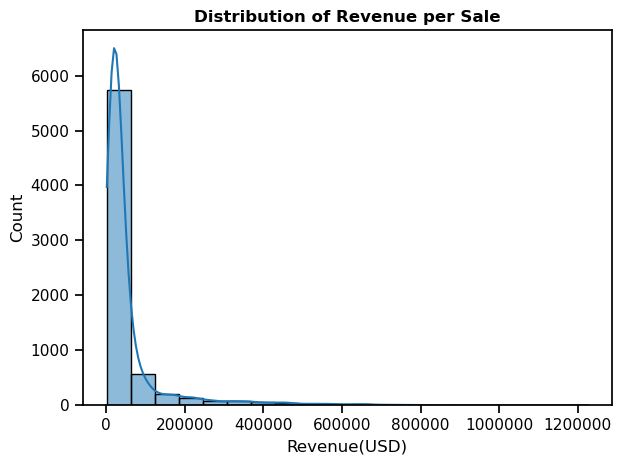

In [21]:
df["revenue_usd"].describe()
sns.histplot(df["revenue_usd"], bins = 20, kde=True)

plt.ticklabel_format(style="plain", axis="x")
plt.title("Distribution of Revenue per Sale", fontweight="bold")
plt.xlabel("Revenue(USD)")
plt.tight_layout()
plt.show()

Revenue per sale is heavily right-skewed, with the vast majority of transactions generating under $100,000, meaning the mean revenue figure is likely inflated by a small number of very high-value sales exceeding (400000 - 1,200,000)USD.

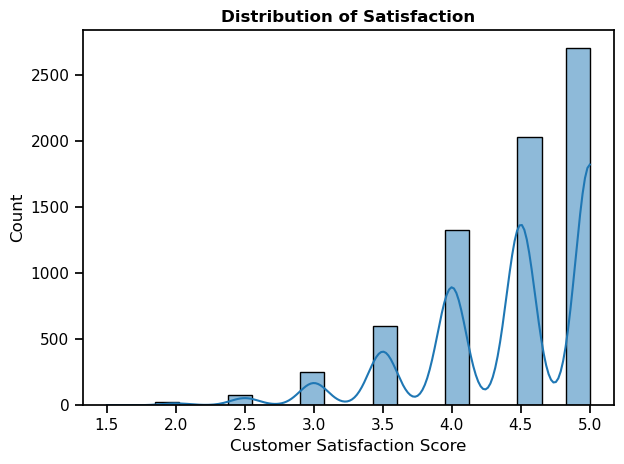

In [22]:
df["customer_satisfaction_score"].describe()
sns.histplot(df["customer_satisfaction_score"], bins = 20, kde=True)

plt.ticklabel_format(style="plain", axis="x")
plt.title("Distribution of Satisfaction", fontweight="bold")
plt.xlabel("Customer Satisfaction Score")
plt.tight_layout()
plt.show()

Customer satisfaction is heavily left-skewed toward the top of the scale with over half of all responses rated 4.5 or above, indicating strong overall satisfaction, though the near-absence of scores below 2.5 may also suggest a ceiling effect or self-selection bias in who responds.

### Bivariate Analysis

In [23]:
stock_stat = df.groupby("stock_status", observed=True)["units_sold"].sum().sort_values(ascending=False)
stock_stat

stock_status
In Stock       67220
Low Stock      42476
Backordered    27048
Sold Out       14975
Name: units_sold, dtype: int64

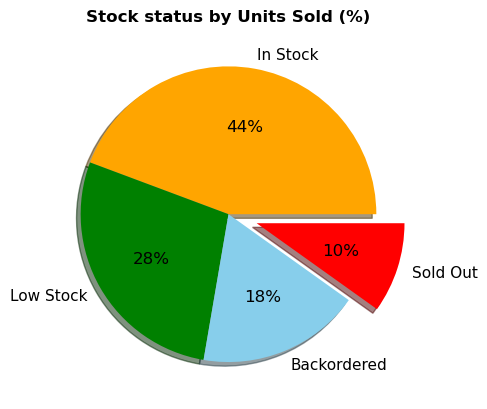

In [24]:
plt.pie(stock_stat.values, labels=stock_stat.index, 
                                    autopct="%1.0f%%",
                                    colors=["orange", "green", "skyblue", "red"],
                                    shadow=True,
                                    explode=[0, 0, 0, 0.2])
plt.title("Stock status by Units Sold (%)", fontweight="bold")
plt.show()

While 44% of units sold came from healthy in-stock inventory, a combined 56% were fulfilled from low-stock, backordered or sold-out situations, signaling significant inventory strain that may be causing lost sales or delayed fulfillment.

## Business Questions

### 1. Which GPU family drives the most sales volume and revenue?

In [25]:
gpu_fam_sales_vol = df.groupby("gpu_family", observed=True)["units_sold"].sum().sort_values(ascending=False)
gpu_fam_sales_vol

gpu_family
Consumer Gaming    144692
Data Center AI       7027
Name: units_sold, dtype: int64

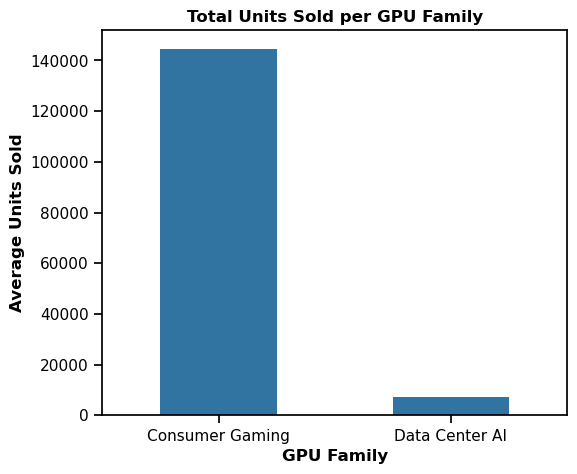

In [26]:
plt.figure(figsize=(6, 5))
sns.barplot(x = gpu_fam_sales_vol.index, y = gpu_fam_sales_vol.values, width=0.5)

plt.title("Total Units Sold per GPU Family", fontweight="bold")
plt.xlabel("GPU Family", fontweight="bold")
plt.ylabel("Average Units Sold", fontweight="bold")
plt.show()

Consumer Gaming GPUs vastly outsell Data Center AI units by roughly 20x, reflecting the difference in market size but given the much higher price point and margins typically associated with AI/data center chips, unit volume alone likely understates their true revenue contribution.

In [27]:
gpu_fam_rev = df.groupby("gpu_family", observed=True)["revenue_usd"].mean().sort_values(ascending=False)
gpu_fam_rev

gpu_family
Data Center AI     216444.509183
Consumer Gaming     27511.348344
Name: revenue_usd, dtype: float64

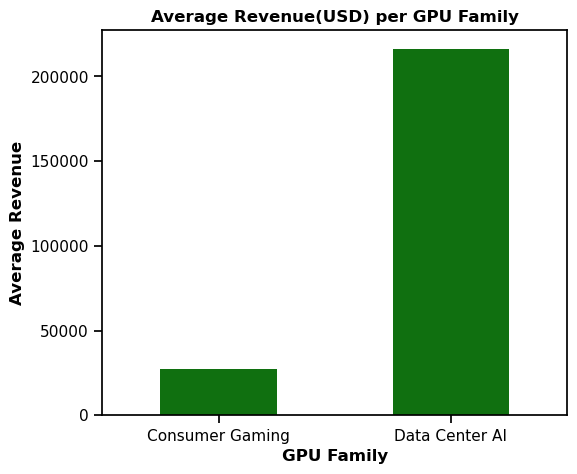

In [28]:
plt.figure(figsize=(6, 5))
sns.barplot(x = gpu_fam_rev.index, y = gpu_fam_rev.values, color="g", width=0.5)

plt.title("Average Revenue(USD) per GPU Family", fontweight="bold")
plt.xlabel("GPU Family", fontweight="bold")
plt.ylabel("Average Revenue", fontweight="bold")
plt.show()

Despite selling 20x fewer units, Data Center AI generates roughly 8x more average revenue per sale (~ $215K vs ~$27K) than Consumer Gaming, indicating AI/data center chips are the far more profitable line on a per-unit basis, even though Consumer Gaming drives overall

In [29]:
gpu_f = df.groupby('gpu_family', observed=True)[['units_sold','revenue_usd']].sum().sort_values('revenue_usd', ascending=False)
gpu_f

,units_sold,revenue_usd
gpu_family,,
Data Center AI,7027,2.331107e+08
Consumer Gaming,144692,1.629497e+08


### 2. Which sales channel gives the best return — highest revenue per unit sold, not just highest volume?

In [30]:
df["sales_channel"].value_counts()

sales_channel
Retail/Etail             4459
System Integrator/OEM    1641
Cloud Provider            530
Direct Enterprise         370
Name: count, dtype: int64

In [31]:
sales = df.groupby("sales_channel", observed=True).apply(lambda x: round(x["revenue_usd"].sum()/ x["units_sold"].sum(), 2), include_groups=False).sort_values(ascending=False)
sales

sales_channel
Direct Enterprise        34604.39
Cloud Provider           31931.80
System Integrator/OEM     2075.00
Retail/Etail              1124.59
dtype: float64

In [32]:
grouped = df.groupby("sales_channel", observed=True)[["revenue_usd", "units_sold"]].sum()
sales2 = (grouped["revenue_usd"] / grouped["units_sold"]).round(2).sort_values(ascending=False)
sales2

sales_channel
Direct Enterprise        34604.39
Cloud Provider           31931.80
System Integrator/OEM     2075.00
Retail/Etail              1124.59
dtype: float64

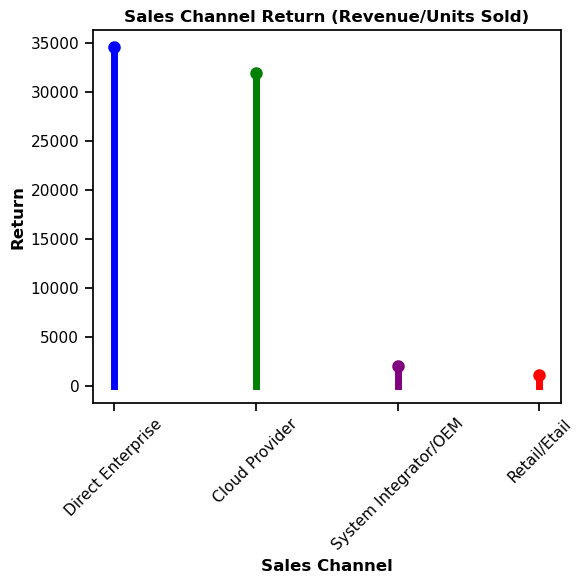

In [33]:
colors = ["blue", "green", "purple", "red"]

fig, ax = plt.subplots(figsize=(6,6))
for i, (cat, val) in enumerate(zip(sales.index, sales.values)):
    ax.plot([i, i], [0, val], color=colors[i], linewidth=5)   # the stem line
    ax.plot(i, val, 'o', color=colors[i], markersize=8)         # the marker/dot

ax.set_xticks(range(len(sales.index)))
ax.set_xticklabels(sales.index, rotation=45)
plt.title("Sales Channel Return (Revenue/Units Sold)", fontweight="bold")
plt.xlabel("Sales Channel", fontweight="bold")
plt.ylabel("Return", fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The near 30x gap between top and bottom channels indicates highly uneven deal economics across the sales mix - Direct Enterprise and Cloud Provider likely represent large-ticket, negotiated sales, while System Integrator/OEM and Retail/Etail operate on a high-volume, lower-margin-per-unit model.

### 3. Is charging above MSRP actually hurting customer satisfaction, or can we get away with it? 

Text(0, 0.5, 'Customer Satisfaction Score')

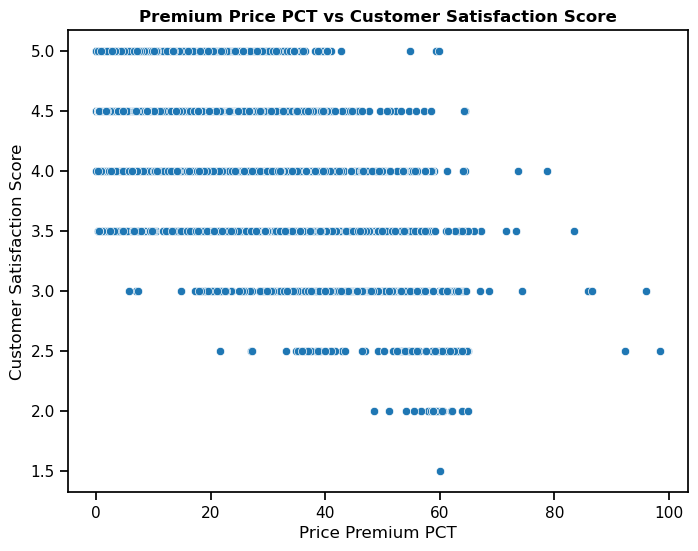

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x = "price_premium_pct", y = "customer_satisfaction_score", data = df)

plt.title("Premium Price PCT vs Customer Satisfaction Score", fontweight="bold")
plt.xlabel("Price Premium PCT")
plt.ylabel("Customer Satisfaction Score")

There's no strong linear relationship between price premium and satisfaction - most scores cluster densely between 0–65% premium across all satisfaction levels - but the lower satisfaction bands (2.0–2.5) only appear at higher premiums (45%+), suggesting steep pricing may become a dissatisfaction risk beyond a certain threshold rather than a steady drag.

In [35]:
df["price_premium_pct"].corr(df["customer_satisfaction_score"])

np.float64(-0.6719544188577681)

In [36]:
df.columns

Index(['sale_id', 'sale_date', 'gpu_model', 'gpu_family', 'launch_year',
       'region', 'sales_channel', 'customer_segment', 'units_sold', 'msrp_usd',
       'avg_street_price_usd', 'price_premium_pct', 'stock_status',
       'customer_satisfaction_score', 'warranty_months', 'bundle_addon',
       'revenue_usd', 'calculated_premium', 'premium_mismatch',
       'calculated_revenue', 'revenue_mismatch'],
      dtype='object')

### 4. Which customer segment is the most valuable, and what do they actually buy?

In [37]:
df.groupby('customer_segment', observed=True)['revenue_usd'].agg(['sum','mean','count']).sort_values(by = "mean", ascending=False)

,sum,mean,count
customer_segment,,,
Crypto Mining,4.398137e+07,245705.986201,179
Hyperscale Datacenter,1.276125e+08,218514.553545,584
AI Research/Startup,6.151687e+07,195913.584682,314
Content Creation,3.263558e+07,28109.890646,1161
Gaming,1.303141e+08,27365.420664,4762


In [38]:
### Number of purchases each customer segments made
pd.crosstab(df['customer_segment'], df['gpu_family'])

gpu_family,Consumer Gaming,Data Center AI
customer_segment,,
AI Research/Startup,0,314
Content Creation,1161,0
Crypto Mining,0,179
Gaming,4762,0
Hyperscale Datacenter,0,584


In [39]:
df["customer_segment"].value_counts()

customer_segment
Gaming                   4762
Content Creation         1161
Hyperscale Datacenter     584
AI Research/Startup       314
Crypto Mining             179
Name: count, dtype: int64

In [40]:
### The most valuable customer segments and the GPU family they are buying from
df.groupby(["customer_segment", "gpu_family"], observed=True)["revenue_usd"].mean().round(2).sort_values(ascending=False)

customer_segment       gpu_family     
Crypto Mining          Data Center AI     245705.99
Hyperscale Datacenter  Data Center AI     218514.55
AI Research/Startup    Data Center AI     195913.58
Content Creation       Consumer Gaming     28109.89
Gaming                 Consumer Gaming     27365.42
Name: revenue_usd, dtype: float64

In [41]:
customer_seg = df.groupby("customer_segment", observed=True)["revenue_usd"].mean().round(2).sort_values(ascending=True)
customer_seg

customer_segment
Gaming                    27365.42
Content Creation          28109.89
AI Research/Startup      195913.58
Hyperscale Datacenter    218514.55
Crypto Mining            245705.99
Name: revenue_usd, dtype: float64

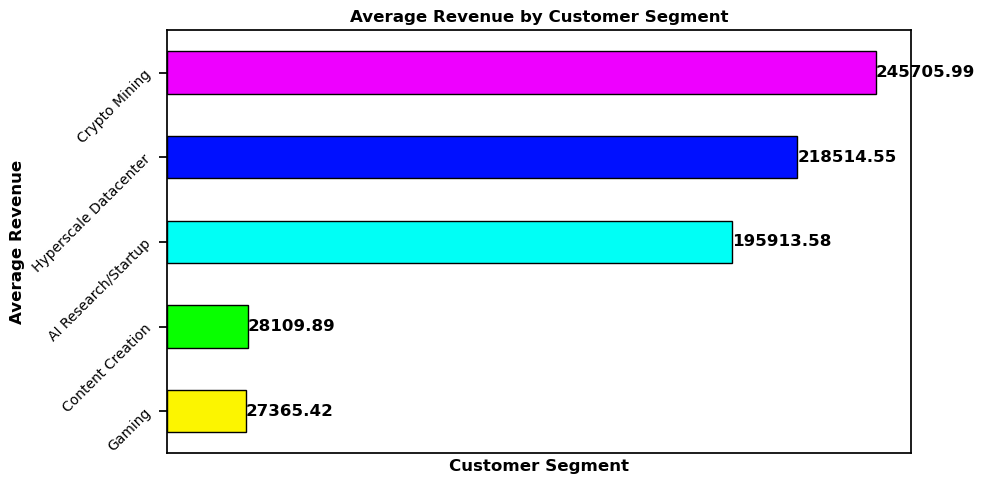

In [42]:
plt.figure(figsize=(10,5))
colors = sns.color_palette("hsv", len(customer_seg))
customer_seg.plot(kind="barh", color=colors, edgecolor="black")
for i, v in enumerate(customer_seg.values):
    plt.text(v + 50, i, str(v), va="center", fontweight="bold")
plt.title("Average Revenue by Customer Segment", fontweight="bold")
plt.xlabel("Customer Segment", fontweight="bold")
plt.ylabel("Average Revenue", fontweight="bold")
plt.yticks(rotation=45, fontsize=10)
plt.xticks([])
plt.tight_layout()
plt.show()

The revenue split falls into two distinct clusters - high-value infrastructure/enterprise segments (Crypto Mining, Hyperscale Datacenter, AI Research) versus consumer-facing segments (Gaming, Content Creation), suggesting sales and account strategies should likely differ significantly between these two groups.

### 5. What are the most valuable GPU models from each GPU family?

In [43]:
### The most valuable GPU models from each GPU family
gpu_model = df.groupby(["gpu_family", "gpu_model"], observed=True)["revenue_usd"].mean().sort_values(ascending=False)
gpu_model.reset_index()
gpu_model

gpu_family       gpu_model        
Data Center AI   B200                 314526.538984
                 H200                 263035.948400
                 H100 SXM             215344.471869
                 A100 80GB            115542.290833
                 L40S                  67195.179245
Consumer Gaming  RTX 5090              56586.309288
                 RTX 4090              44052.477431
                 RTX 4080 Super        28429.970814
                 RTX 5080              27946.425018
                 RTX 4070 Ti Super     22441.319701
                 RTX 5070 Ti           21416.400982
                 RTX 5070              15117.259148
Name: revenue_usd, dtype: float64

In [44]:
Data_Center_AI = df[df["gpu_family"] == "Data Center AI"]
Data_Center_AI.head(3)

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,...,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd,calculated_premium,premium_mismatch,calculated_revenue,revenue_mismatch
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,...,8.16,Low Stock,4.5,24,No bundle,146010.54,8.155963,False,146010.55,False
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,...,2.88,In Stock,4.5,36,No bundle,250008.56,2.884185,False,250008.57,False
9,10,2024-02-25,H100 SXM,Data Center AI,2022,North America,Direct Enterprise,Hyperscale Datacenter,7,27000,...,57.19,Sold Out,4.0,24,No bundle,297097.88,57.194630,False,297097.85,False


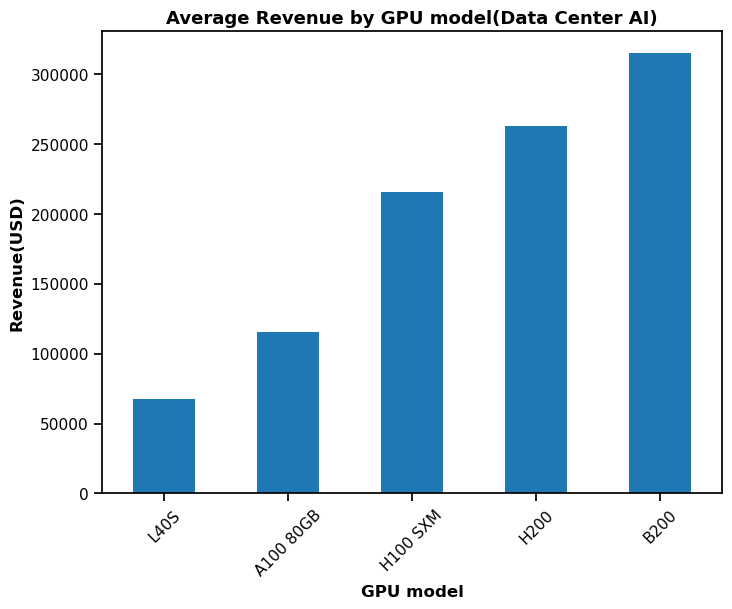

In [45]:
rev1 = Data_Center_AI.groupby("gpu_model", observed=True)["revenue_usd"].mean().sort_values(ascending=True)
rev1.plot(kind="bar", figsize=(8,6))
plt.title("Average Revenue by GPU model(Data Center AI)", fontsize=13, fontweight="bold")
plt.xlabel("GPU model", fontweight="bold")
plt.ylabel("Revenue(USD)", fontweight="bold")
plt.xticks(rotation=45)
plt.show()

Average revenue rises consistently with GPU tier - from ~$68K for the L40S to over $315K for the B200 - nearly a 4.6x increase, confirming that newer/higher-performance chips command significantly higher deal sizes within the Data Center AI segment.

In [46]:
Consumer_Gaming = df[df["gpu_family"] == "Consumer Gaming"]
Consumer_Gaming.head(3)

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,...,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd,calculated_premium,premium_mismatch,calculated_revenue,revenue_mismatch
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,...,12.38,Low Stock,4.0,12,Software Bundle,14375.30,12.377111,False,14375.28,False
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,...,20.74,Low Stock,5.0,12,No bundle,32799.82,20.738423,False,32799.80,False
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,...,30.96,Sold Out,4.0,12,No bundle,39247.64,30.955956,False,39247.50,False


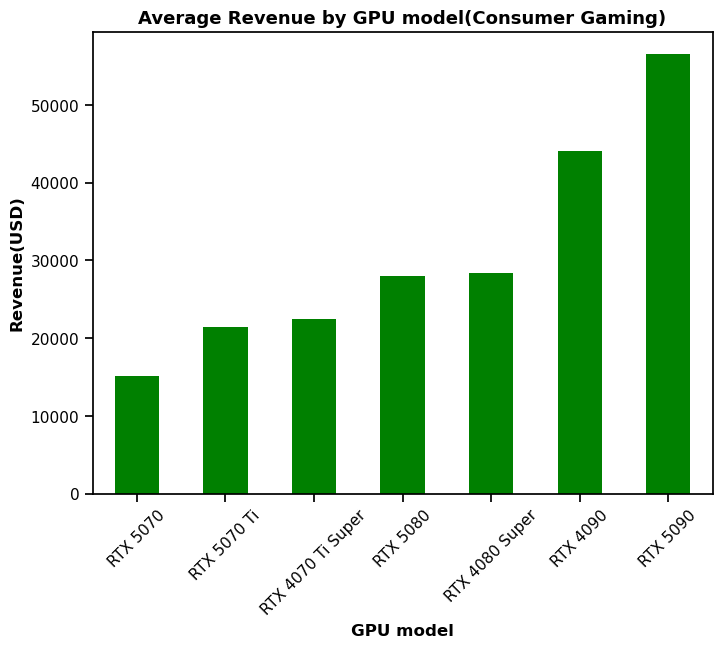

In [47]:
rev1 = Consumer_Gaming.groupby("gpu_model", observed=True)["revenue_usd"].mean().sort_values(ascending=True)
rev1.plot(kind="bar", figsize=(8,6), color="green")
plt.title("Average Revenue by GPU model(Consumer Gaming)", fontsize=13, fontweight="bold")
plt.xlabel("GPU model", fontweight="bold")
plt.ylabel("Revenue(USD)", fontweight="bold")
plt.xticks(rotation=45)
plt.show()

Higher-tier GPU models earn more revenue, with the RTX 5090 leading at over $56,000, nearly 4 times higher than the entry-level RTX 5070. This shows customers who buy premium models add much more revenue per sale.

In [48]:
### The most sold GPU models
df.groupby(["gpu_family", "gpu_model"], observed=True)[["revenue_usd", "units_sold"]].sum().sort_values(by = "units_sold", ascending=False)

revenue_usd  units_sold
gpu_family      gpu_model                                 
Consumer Gaming RTX 5070           19168684.60       30454
                RTX 5070 Ti        22679968.64       26361
                RTX 4070 Ti Super  21027516.56       22944
                RTX 5080           23502943.44       20419
                RTX 4080 Super     19218660.27       16672
                RTX 4090           25550436.91       13930
                RTX 5090           31801505.82       13912
Data Center AI  B200               95930594.39        1943
                H200               65758987.10        1646
                H100 SXM           46083716.98        1461
                L40S               14245378.00        1366
                A100 80GB          11092059.92         611

### 6. Are bundles actually worth offering, or are they just added cost with no return?

In [49]:
df.groupby("bundle_addon", observed=True)["revenue_usd"].agg(["sum", "mean", "count"]).sort_values(by = "mean", ascending=False)

,sum,mean,count
bundle_addon,,,
Support Contract,7.730181e+07,210059.263723,368
NVLink Cluster Install,3.350060e+07,199408.306726,168
No bundle,2.132465e+08,55518.480896,3841
Cooling Kit,1.745580e+07,29190.297207,598
Extended Warranty,3.157915e+07,27083.321115,1166
Software Bundle,2.297661e+07,26748.094040,859


In [50]:
# df.groupby("bundle_addon", observed=True)[["revenue_usd", "customer_satisfaction_score"]].mean()
pd.crosstab(
    index=df['bundle_addon'],
    columns=df['customer_segment'],
    values=df['revenue_usd'],
    aggfunc='mean'
).round(2)

customer_segment,AI Research/Startup,Content Creation,Crypto Mining,Gaming,Hyperscale Datacenter
bundle_addon,,,,,
Cooling Kit,NaN,29496.36,NaN,29115.85,NaN
Extended Warranty,NaN,28723.46,NaN,26693.31,NaN
NVLink Cluster Install,182099.92,NaN,170059.46,NaN,215120.35
No bundle,202392.97,28171.72,275171.33,27408.54,223999.69
Software Bundle,NaN,26203.43,NaN,26890.46,NaN
Support Contract,192119.43,NaN,240962.62,NaN,211436.09


In [51]:
df.groupby(['bundle_addon', 'customer_segment'], observed=True)['revenue_usd'].mean()

bundle_addon            customer_segment     
Cooling Kit             Content Creation          29496.362564
                        Gaming                    29115.848877
Extended Warranty       Content Creation          28723.462321
                        Gaming                    26693.308769
NVLink Cluster Install  AI Research/Startup      182099.920513
                        Crypto Mining            170059.457333
                        Hyperscale Datacenter    215120.352626
No bundle               AI Research/Startup      202392.972597
                        Content Creation          28171.717212
                        Crypto Mining            275171.328391
                        Gaming                    27408.544342
                        Hyperscale Datacenter    223999.694867
Software Bundle         Content Creation          26203.430393
                        Gaming                    26890.458399
Support Contract        AI Research/Startup      192119.429008
         

### 7. Is there a seasonal pattern we should be planning inventory and promotions around?

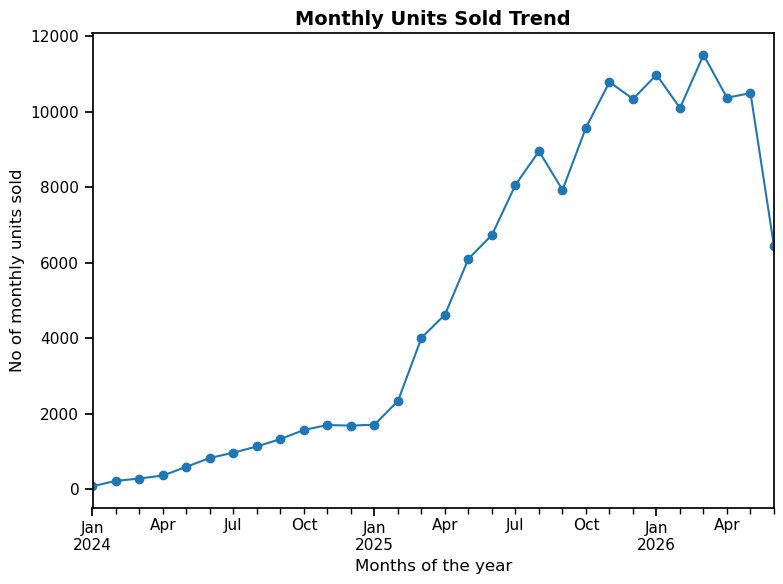

In [52]:
df.set_index('sale_date').resample('ME')['units_sold'].sum().plot(figsize=(8, 6), marker="o")
plt.title("Monthly Units Sold Trend", fontweight="bold", fontsize=14)
plt.xlabel("Months of the year")
plt.ylabel("No of monthly units sold")
plt.tight_layout()
plt.show()

Monthly units sold grew slowly from Jan 2024 to Dec 2024, then jumped sharply from Jan to Mar 2025, reaching around 4,000 units. Sales kept rising through late 2025 and stayed strong near 10,000–11,500 units into 2026, before a sudden drop in the last month.

In [53]:
df_2026 = df[df["sale_date"].dt.year == 2026]
months_2026 = df_2026["sale_date"].dt.month_name().unique()
print(months_2026)

['January' 'February' 'March' 'April' 'May' 'June']


### 8. Which region offers the best pricing power — highest premium tolerated without hurting volume?

In [54]:
df.groupby("region", observed=True).agg({"price_premium_pct": "mean", "units_sold":"sum"}).sort_values(by = "price_premium_pct", ascending = False)

,price_premium_pct,units_sold
region,,
China,15.966791,23362
Asia-Pacific (ex-China),15.002941,31288
Europe,14.977880,36755
North America,14.678683,48926
Rest of World,14.620476,11388


### 9. Does a longer warranty actually justify a higher price premium in the eyes of customers?

In [55]:
df.groupby("warranty_months")["price_premium_pct"].mean()

warranty_months
12    14.982756
24    14.909271
36    15.355854
Name: price_premium_pct, dtype: float64

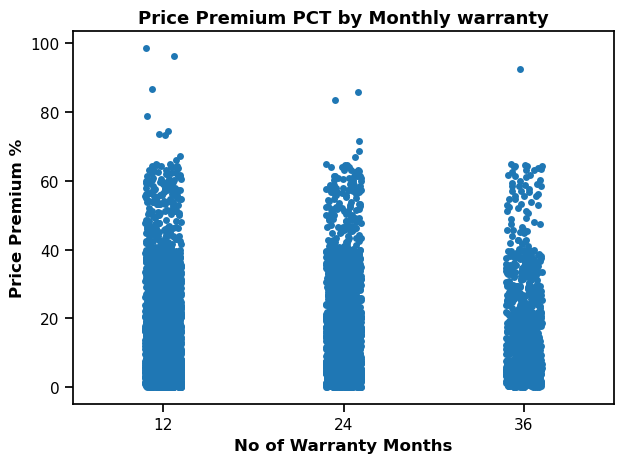

In [56]:
sns.stripplot(data=df, x='warranty_months', y='price_premium_pct', dodge=True)
plt.title("Price Premium PCT by Monthly warranty", fontsize=13, fontweight="bold")
plt.xlabel("No of Warranty Months", fontweight="bold")
plt.ylabel("Price Premium %", fontweight="bold")

plt.tight_layout()
plt.show()

There is no big difference in price premium between the three warranty groups — each one shows a similar wide spread from 0% to 60%+. This suggests warranty length alone does not strongly drive how much extra price a product carries.

In [57]:
df["warranty_months"].corr(df["price_premium_pct"])

np.float64(0.006180418745510479)

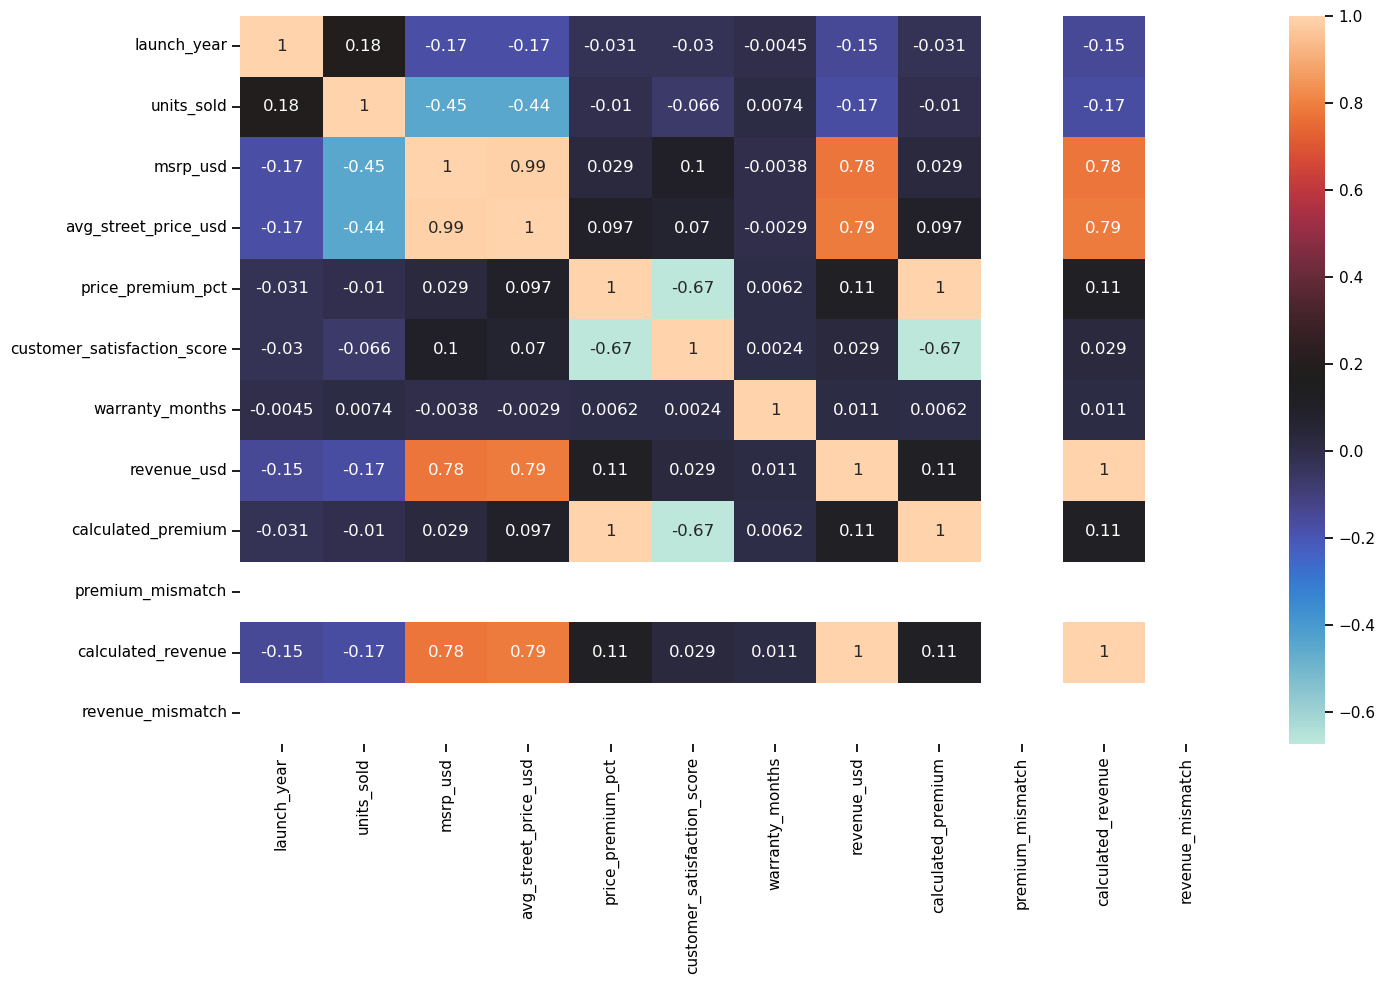

In [58]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap="icefire")
plt.tight_layout()
plt.show()

Revenue is strongly linked to price (0.78–0.79) but barely linked to units sold (-0.17), confirming that price drives revenue more than volume does. Price premium and customer satisfaction move in opposite directions (-0.67), suggesting higher premiums may lower satisfaction.

## MINI DASHBOARD

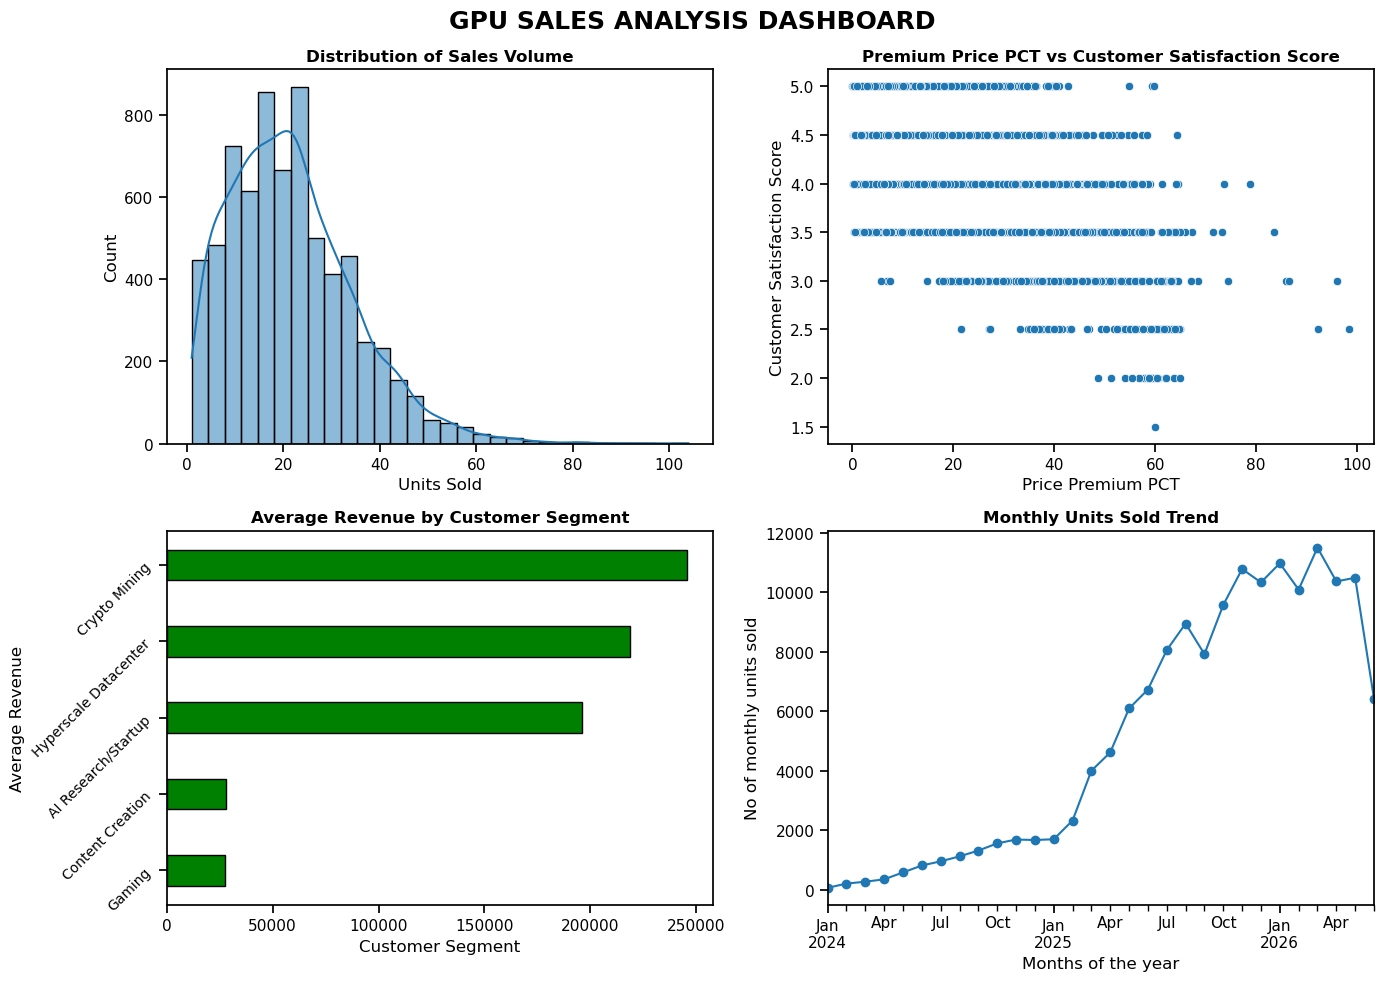

In [59]:
## create dashboard layout
plt.figure(figsize=(14, 10))

## 1. Distribution of Sales Volume
plt.subplot(2,2,1)
sns.histplot(df["units_sold"], bins = 30, kde=True)
plt.title("Distribution of Sales Volume", fontweight="bold")
plt.xlabel("Units Sold")

## 2. Premium Price PCT vs Customer Satisfaction Score
plt.subplot(2,2,2)
sns.scatterplot(x = "price_premium_pct", y = "customer_satisfaction_score", data = df)
plt.title("Premium Price PCT vs Customer Satisfaction Score", fontweight="bold")
plt.xlabel("Price Premium PCT")
plt.ylabel("Customer Satisfaction Score")

## 3. Average Revenue by Customer Segment
plt.subplot(2,2,3)
customer_seg.plot(kind="barh", color="green", edgecolor="black", width=0.4)
plt.title("Average Revenue by Customer Segment", fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue")
plt.yticks(rotation=45, fontsize=10)

## 4. Monthly Units Sold Trend
plt.subplot(2,2,4)
df.set_index('sale_date').resample('ME')['units_sold'].sum().plot(marker="o")
plt.title("Monthly Units Sold Trend", fontweight="bold")
plt.xlabel("Months of the year")
plt.ylabel("No of monthly units sold")

plt.suptitle("GPU SALES ANALYSIS DASHBOARD", fontsize=18, fontweight= "bold")

plt.tight_layout()
plt.show()